In [6]:

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [7]:
def calc_gflops(N, time_ms):
    t_sec = time_ms / 1000.0
    return (2 * (N ** 3)) / t_sec / 1e9


def speedup(new, old):
    return new / old


def efficiency_percent(base, improved):
    return (improved / base - 1) * 100


def add_record(records, algorithm, N, time_ms, perf=None, S=None, M=None,
               correctness=None, transpose_included=None, note=None):
    if perf is None and time_ms is not None:
        perf = calc_gflops(N, time_ms)
    records.append({
        "algorithm": algorithm,
        "N": N,
        "S": S,
        "M": M,
        "time_ms": time_ms,
        "perf_gflops": perf,
        "correctness": correctness,
        "transpose_included": transpose_included,
        "note": note
    })

In [8]:
import re
import pandas as pd


def _to_number(x):
    if x is None:
        return None
    if "." in str(x):
        return float(x)
    return int(x)


def _clean_raw_text(raw_text: str) -> str:
    """
    Удаляет префиксы чата вида:
    [23.03.2026 14:34] Григорий Исупов:
    но сохраняет сам benchmark-текст.
    """
    text = raw_text.replace("\r\n", "\n").replace("\r", "\n")

    # Убираем префиксы сообщений чата в начале строк
    text = re.sub(
        r"^\[\d{2}\.\d{2}\.\d{4}\s+\d{2}:\d{2}\]\s+.*?:\s*",
        "",
        text,
        flags=re.M
    )

    # Иногда "Fill matrixCalculate matrix" слипается
    text = text.replace("Fill matrixCalculate matrix", "Fill matrix\nCalculate matrix")
    text = text.replace("Fill matrix\nCalculate matrix", "Fill matrix\nCalculate matrix\n")

    # Сжимаем слишком длинные пустые участки
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def parse_benchmark_text(raw_text: str):
    text = _clean_raw_text(raw_text)

    summary_records = []
    buffered_records = []
    blocked_records = []
    correctness_records = []

    current_N = None

    # Общие regex'ы
    re_header_N = re.compile(r"^\s*N\s*=\s*(\d+)\s*$", re.I)

    re_buffered_detail = re.compile(
        r"Buffered:\s*M\s*=\s*(\d+),\s*N\s*=\s*(\d+),\s*t\s*=\s*([\d.]+)\s*ms,\s*P\s*=\s*([\d.]+)\s*GFLOP/s",
        re.I
    )
    re_blocked_detail = re.compile(
        r"Blocked:\s*S\s*=\s*(\d+),\s*M\s*=\s*(\d+),\s*N\s*=\s*(\d+),\s*t\s*=\s*([\d.]+)\s*ms,\s*P\s*=\s*([\d.]+)\s*GFLOP/s",
        re.I
    )

    re_summary_generic = re.compile(
        r"^(Classic|Transposed\s*\(\+prep\)|Transposed only|Buffered|Blocked)"
        r"\s+N\s*=\s*(\d+)\s+time\s*=\s*([\d.]+)\s*ms\s+perf\s*=\s*([\d.]+)\s*GFLOP/s\s*$",
        re.I
    )

    re_best_buffered = re.compile(r"^Buffered:\s*M\s*=\s*(\d+)\s*$", re.I)
    re_best_blocked = re.compile(r"^Blocked\s*:\s*S\s*=\s*(\d+),\s*M\s*=\s*(\d+)\s*$", re.I)

    re_correctness = re.compile(
        r"^(Classic vs Transposed|Classic vs Buffered|Classic vs Blocked)\s*:\s*(OK|FAIL)\s*$",
        re.I
    )

    # Чтобы позже проставить лучшие параметры в summary
    best_params_by_n = {}

    lines = [line.strip() for line in text.split("\n")]

    for line in lines:
        if not line:
            continue

        # ---------- N header ----------
        m = re_header_N.match(line)
        if m:
            current_N = int(m.group(1))
            best_params_by_n.setdefault(current_N, {})
            continue

        # ---------- Detailed Buffered ----------
        m = re_buffered_detail.search(line)
        if m:
            M, N, t, p = m.groups()
            buffered_records.append({
                "algorithm": "Buffered",
                "N": int(N),
                "M": int(M),
                "time_ms": float(t),
                "perf_gflops": float(p),
            })
            continue

        # ---------- Detailed Blocked ----------
        m = re_blocked_detail.search(line)
        if m:
            S, M, N, t, p = m.groups()
            blocked_records.append({
                "algorithm": "Blocked",
                "N": int(N),
                "S": int(S),
                "M": int(M),
                "time_ms": float(t),
                "perf_gflops": float(p),
            })
            continue

        # ---------- Summary ----------
        m = re_summary_generic.match(line)
        if m:
            algorithm, N, t, p = m.groups()
            N = int(N)

            algorithm = re.sub(r"\s+", " ", algorithm).strip()
            row = {
                "algorithm": algorithm,
                "N": N,
                "time_ms": float(t),
                "perf_gflops": float(p),
            }

            if algorithm == "Transposed (+prep)":
                row["transpose_included"] = True
            elif algorithm == "Transposed only":
                row["transpose_included"] = False

            summary_records.append(row)
            continue

        # ---------- Best params ----------
        m = re_best_buffered.match(line)
        if m and current_N is not None:
            best_params_by_n.setdefault(current_N, {})
            best_params_by_n[current_N]["buffered_M"] = int(m.group(1))
            continue

        m = re_best_blocked.match(line)
        if m and current_N is not None:
            S, M = m.groups()
            best_params_by_n.setdefault(current_N, {})
            best_params_by_n[current_N]["blocked_S"] = int(S)
            best_params_by_n[current_N]["blocked_M"] = int(M)
            continue

        # ---------- Correctness ----------
        m = re_correctness.match(line)
        if m:
            compare_name, status = m.groups()
            correctness_records.append({
                "N": current_N,
                "comparison": compare_name,
                "status": status.upper(),
            })
            continue

    # --- DataFrames ---
    df_summary = pd.DataFrame(summary_records)
    df_buffered = pd.DataFrame(buffered_records)
    df_blocked = pd.DataFrame(blocked_records)
    df_correctness = pd.DataFrame(correctness_records)

    # --- Подставляем лучшие параметры в summary ---
    if not df_summary.empty:
        if "M" not in df_summary.columns:
            df_summary["M"] = pd.NA
        if "S" not in df_summary.columns:
            df_summary["S"] = pd.NA

        for n, params in best_params_by_n.items():
            mask_buf = (df_summary["N"] == n) & (df_summary["algorithm"] == "Buffered")
            if "buffered_M" in params:
                df_summary.loc[mask_buf, "M"] = params["buffered_M"]

            mask_blk = (df_summary["N"] == n) & (df_summary["algorithm"] == "Blocked")
            if "blocked_S" in params:
                df_summary.loc[mask_blk, "S"] = params["blocked_S"]
            if "blocked_M" in params:
                df_summary.loc[mask_blk, "M"] = params["blocked_M"]

        df_summary = df_summary.sort_values(["N", "algorithm"]).reset_index(drop=True)

    if not df_buffered.empty:
        df_buffered = df_buffered.sort_values(["N", "M"]).reset_index(drop=True)

    if not df_blocked.empty:
        df_blocked = df_blocked.sort_values(["N", "S", "M"]).reset_index(drop=True)

    if not df_correctness.empty:
        df_correctness = df_correctness.sort_values(["N", "comparison"]).reset_index(drop=True)

    # --- Лучшие buffered по N ---
    if not df_buffered.empty:
        df_best_buffered = (
            df_buffered.sort_values(["N", "perf_gflops"], ascending=[True, False])
            .groupby("N", as_index=False)
            .first()[["N", "M", "time_ms", "perf_gflops"]]
            .rename(columns={
                "M": "best_M",
                "time_ms": "best_time_ms",
                "perf_gflops": "best_perf_gflops"
            })
        )
    else:
        df_best_buffered = pd.DataFrame()

    # --- Лучшие blocked по N ---
    if not df_blocked.empty:
        df_best_blocked = (
            df_blocked.sort_values(["N", "perf_gflops"], ascending=[True, False])
            .groupby("N", as_index=False)
            .first()[["N", "S", "M", "time_ms", "perf_gflops"]]
            .rename(columns={
                "S": "best_S",
                "M": "best_M",
                "time_ms": "best_time_ms",
                "perf_gflops": "best_perf_gflops"
            })
        )
    else:
        df_best_blocked = pd.DataFrame()

    # --- Лучший алгоритм вообще для каждого N ---
    if not df_summary.empty:
        df_best_per_n = (
            df_summary.sort_values(["N", "perf_gflops"], ascending=[True, False])
            .groupby("N", as_index=False)
            .first()[["N", "algorithm", "time_ms", "perf_gflops", "S", "M"]]
            .rename(columns={
                "algorithm": "best_algorithm",
                "time_ms": "best_time_ms",
                "perf_gflops": "best_perf_gflops",
            })
        )
    else:
        df_best_per_n = pd.DataFrame()

    return {
        "summary_records": summary_records,
        "buffered_records": buffered_records,
        "blocked_records": blocked_records,
        "correctness_records": correctness_records,
        "df_summary": df_summary,
        "df_buffered": df_buffered,
        "df_blocked": df_blocked,
        "df_correctness": df_correctness,
        "df_best_buffered": df_best_buffered,
        "df_best_blocked": df_best_blocked,
        "df_best_per_n": df_best_per_n,
        "clean_text": text,
    }

In [9]:
with open("res.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

parsed = parse_benchmark_text(raw_text)

df_summary = parsed["df_summary"]
df_buffered = parsed["df_buffered"]
df_blocked = parsed["df_blocked"]
df_correctness = parsed["df_correctness"]
df_best_per_n = parsed["df_best_per_n"]

print(df_summary)
print(df_best_per_n)

             algorithm     N    time_ms  perf_gflops transpose_included     M     S
0              Blocked    16      0.002        4.551                NaN    16    16
1             Buffered    16      0.003        3.151                NaN     2  <NA>
2              Classic    16      0.001        9.102                NaN  <NA>  <NA>
3   Transposed (+prep)    16      0.001        9.102               True  <NA>  <NA>
4      Transposed only    16      0.001        9.102              False  <NA>  <NA>
5              Blocked    32      0.009        7.533                NaN     8    32
6             Buffered    32      0.019        3.468                NaN    16  <NA>
7              Classic    32      0.014        4.648                NaN  <NA>  <NA>
8   Transposed (+prep)    32      0.014        4.784               True  <NA>  <NA>
9      Transposed only    32      0.012        5.461              False  <NA>  <NA>
10             Blocked    64      0.071        7.384                NaN     

In [10]:
debug_release = pd.DataFrame([
    {"N": 8192, "config": "Debug", "algorithm": "Classic", "time_ms": 2474577.163, "perf_gflops": 0.444},
    {"N": 8192, "config": "Release", "algorithm": "Classic", "time_ms": 2163416.563, "perf_gflops": 0.508},
])

debug_release

,N,config,algorithm,time_ms,perf_gflops
0,8192,Debug,Classic,2474577.163,0.444
1,8192,Release,Classic,2163416.563,0.508


In [11]:
dbg = debug_release.loc[debug_release["config"] == "Debug"].iloc[0]
rel = debug_release.loc[debug_release["config"] == "Release"].iloc[0]

classic_speedup = speedup(dbg["time_ms"], rel["time_ms"])
perf_gain = speedup(rel["perf_gflops"], dbg["perf_gflops"])
time_reduction_percent = (1 - rel["time_ms"] / dbg["time_ms"]) * 100
perf_increase_percent = (rel["perf_gflops"] / dbg["perf_gflops"] - 1) * 100

print(f"N = 8192")
print(f"Debug time   = {dbg['time_ms']:.3f} ms")
print(f"Release time = {rel['time_ms']:.3f} ms")
print(f"Ускорение по времени = {classic_speedup:.3f}x")
print(f"Сокращение времени   = {time_reduction_percent:.2f}%")
print(f"Рост производительности = {perf_increase_percent:.2f}%")
print(f"Рост GFLOP/s = {perf_gain:.3f}x")

N = 8192
Debug time   = 2474577.163 ms
Release time = 2163416.563 ms
Ускорение по времени = 1.144x
Сокращение времени   = 12.57%
Рост производительности = 14.41%
Рост GFLOP/s = 1.144x


In [12]:
best_buffered = (
    df_buffered.sort_values(["N", "perf_gflops"], ascending=[True, False])
    .groupby("N", as_index=False)
    .first()[["N", "M", "time_ms", "perf_gflops"]]
    .rename(columns={
        "M": "best_M",
        "time_ms": "best_time_ms",
        "perf_gflops": "best_perf_gflops"
    })
)

best_buffered

,N,best_M,best_time_ms,best_perf_gflops
0,16,2,0.003,3.277
1,32,16,0.009,7.202
2,64,8,0.055,9.515
3,128,4,0.410,10.235
4,256,2,3.168,10.591
5,512,8,25.890,10.368
6,1024,8,203.206,10.568
7,2048,2,1864.631,9.214


In [13]:
best_buffered = (
    df_buffered.sort_values(["N", "perf_gflops"], ascending=[True, False])
    .groupby("N", as_index=False)
    .first()[["N", "M", "time_ms", "perf_gflops"]]
    .rename(columns={
        "M": "best_M",
        "time_ms": "best_time_ms",
        "perf_gflops": "best_perf_gflops"
    })
)

best_buffered

,N,best_M,best_time_ms,best_perf_gflops
0,16,2,0.003,3.277
1,32,16,0.009,7.202
2,64,8,0.055,9.515
3,128,4,0.410,10.235
4,256,2,3.168,10.591
5,512,8,25.890,10.368
6,1024,8,203.206,10.568
7,2048,2,1864.631,9.214


In [14]:
best_algorithms = df_summary.copy()
best_algorithms = best_algorithms.sort_values(["N", "algorithm"]).reset_index(drop=True)
best_algorithms

,algorithm,N,time_ms,perf_gflops,transpose_included,M,S
0,Blocked,16,0.002,4.551,NaN,16,16
1,Buffered,16,0.003,3.151,NaN,2,<NA>
2,Classic,16,0.001,9.102,NaN,<NA>,<NA>
3,Transposed (+prep),16,0.001,9.102,True,<NA>,<NA>
4,Transposed only,16,0.001,9.102,False,<NA>,<NA>
5,Blocked,32,0.009,7.533,NaN,8,32
6,Buffered,32,0.019,3.468,NaN,16,<NA>
7,Classic,32,0.014,4.648,NaN,<NA>,<NA>
8,Transposed (+prep),32,0.014,4.784,True,<NA>,<NA>
9,Transposed only,32,0.012,5.461,False,<NA>,<NA>


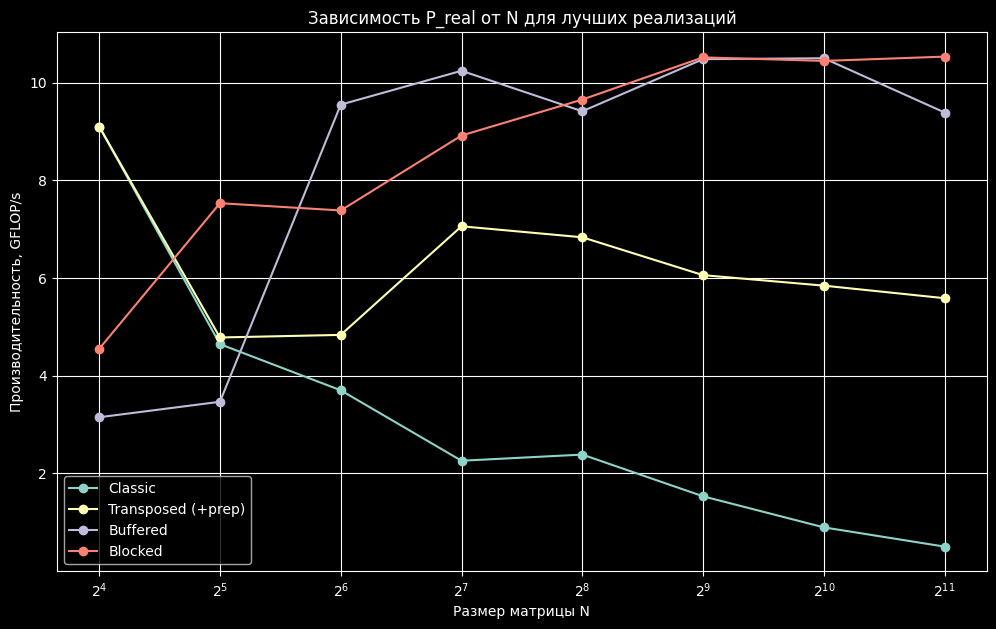

In [15]:
plt.figure(figsize=(12, 7))

for alg in ["Classic", "Transposed (+prep)", "Buffered", "Blocked"]:
    part = df_summary[df_summary["algorithm"] == alg].sort_values("N")
    plt.plot(part["N"], part["perf_gflops"], marker="o", label=alg)

plt.xscale("log", base=2)
plt.xlabel("Размер матрицы N")
plt.ylabel("Производительность, GFLOP/s")
plt.title("Зависимость P_real от N для лучших реализаций")
plt.legend()
plt.show()

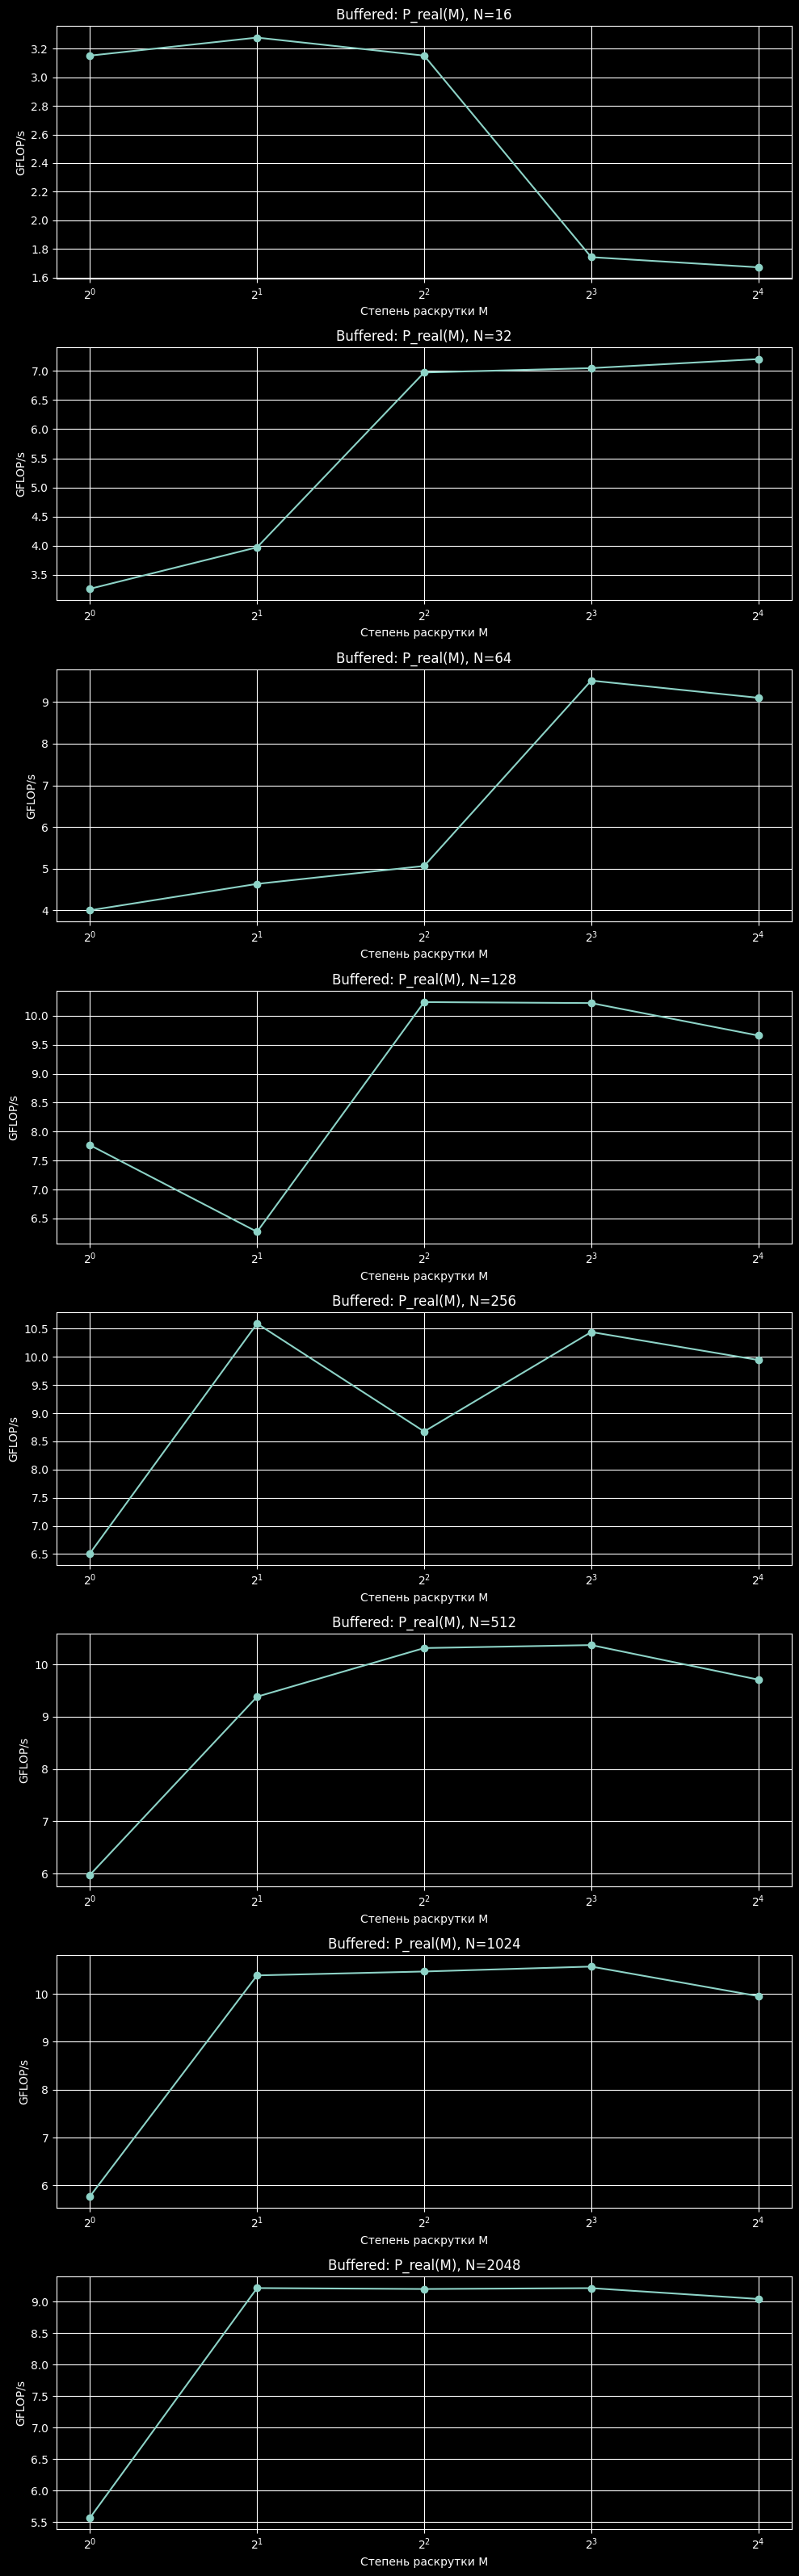

In [16]:
unique_N = sorted(df_buffered["N"].unique())

fig, axes = plt.subplots(len(unique_N), 1, figsize=(10, 4 * len(unique_N)))
if len(unique_N) == 1:
    axes = [axes]

for ax, N in zip(axes, unique_N):
    part = df_buffered[df_buffered["N"] == N].sort_values("M")
    ax.plot(part["M"], part["perf_gflops"], marker="o")
    ax.set_xscale("log", base=2)
    ax.set_title(f"Buffered: P_real(M), N={N}")
    ax.set_xlabel("Степень раскрутки M")
    ax.set_ylabel("GFLOP/s")

plt.tight_layout()
plt.show()

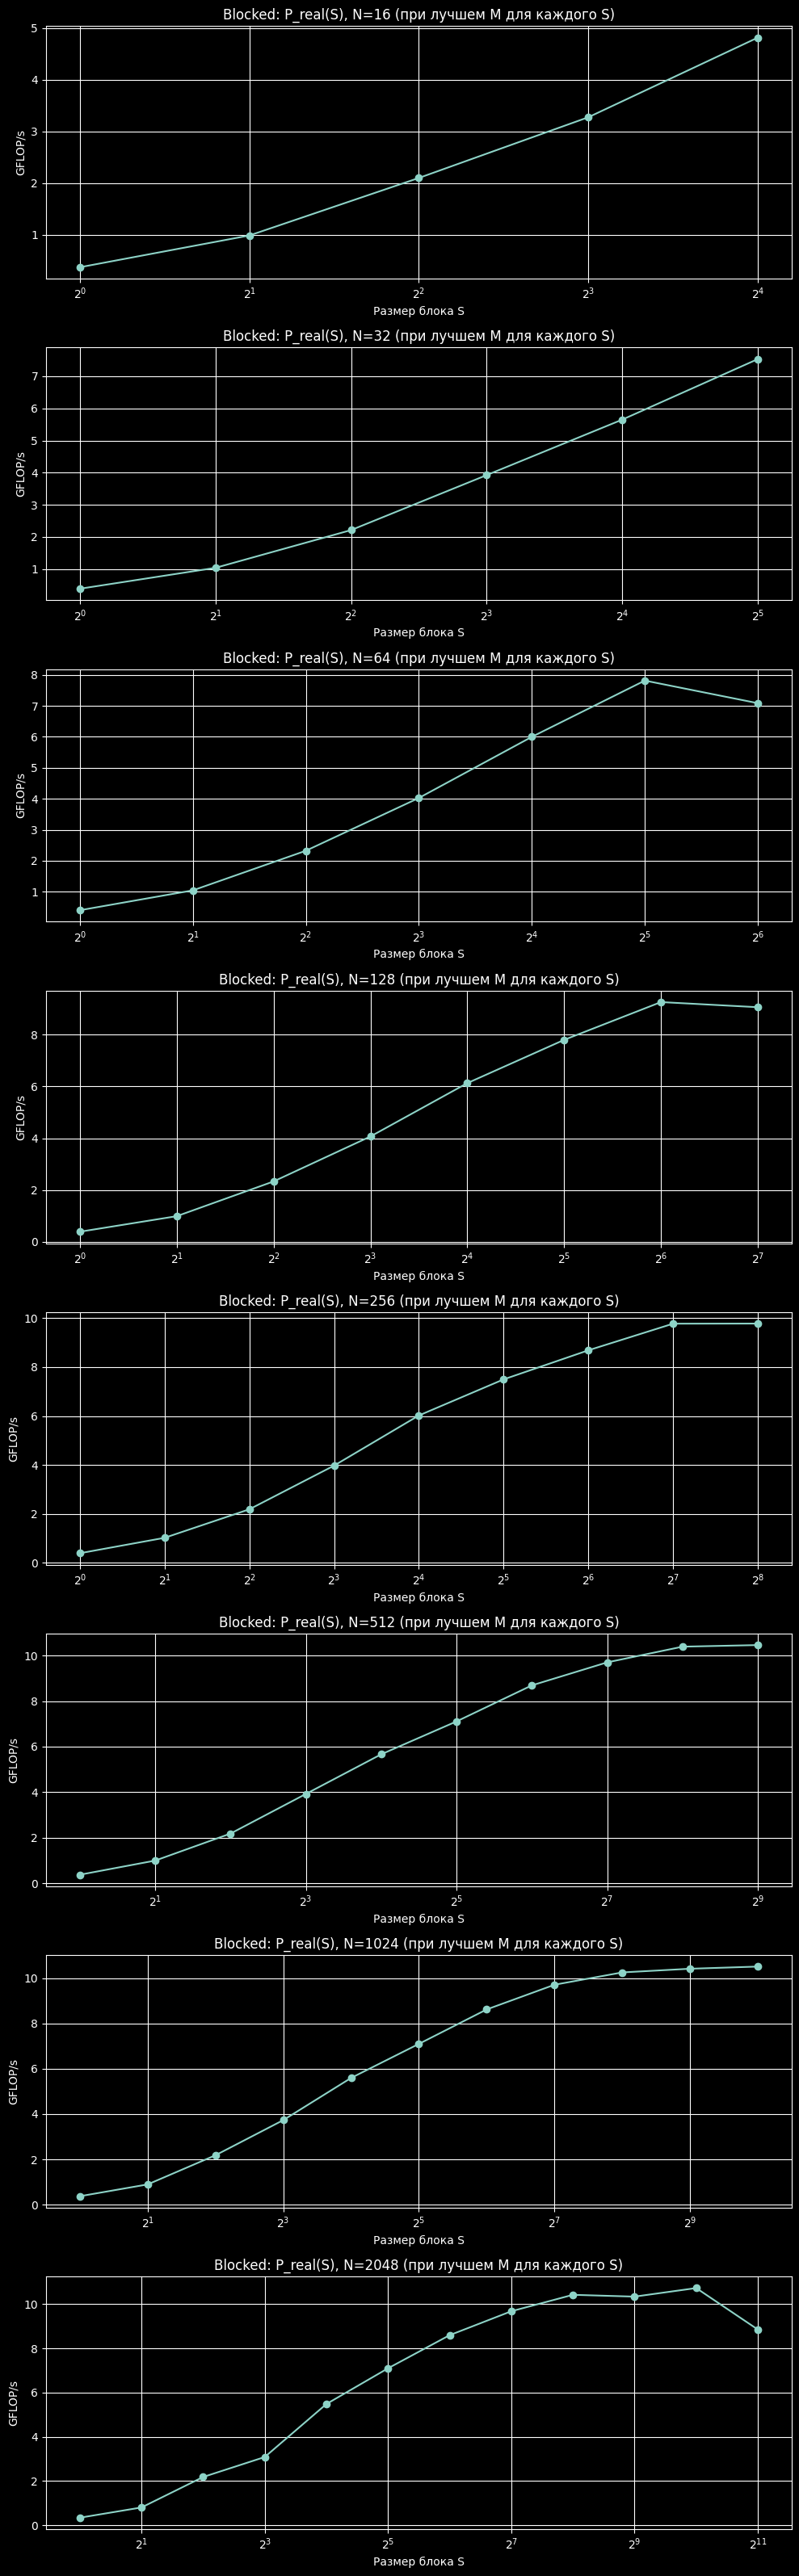

In [17]:
blocked_best_by_S = (
    df_blocked.sort_values(["N", "S", "perf_gflops"], ascending=[True, True, False])
    .groupby(["N", "S"], as_index=False)
    .first()
)

unique_N = sorted(blocked_best_by_S["N"].unique())

fig, axes = plt.subplots(len(unique_N), 1, figsize=(10, 4 * len(unique_N)))
if len(unique_N) == 1:
    axes = [axes]

for ax, N in zip(axes, unique_N):
    part = blocked_best_by_S[blocked_best_by_S["N"] == N].sort_values("S")
    ax.plot(part["S"], part["perf_gflops"], marker="o")
    ax.set_xscale("log", base=2)
    ax.set_title(f"Blocked: P_real(S), N={N} (при лучшем M для каждого S)")
    ax.set_xlabel("Размер блока S")
    ax.set_ylabel("GFLOP/s")

plt.tight_layout()
plt.show()

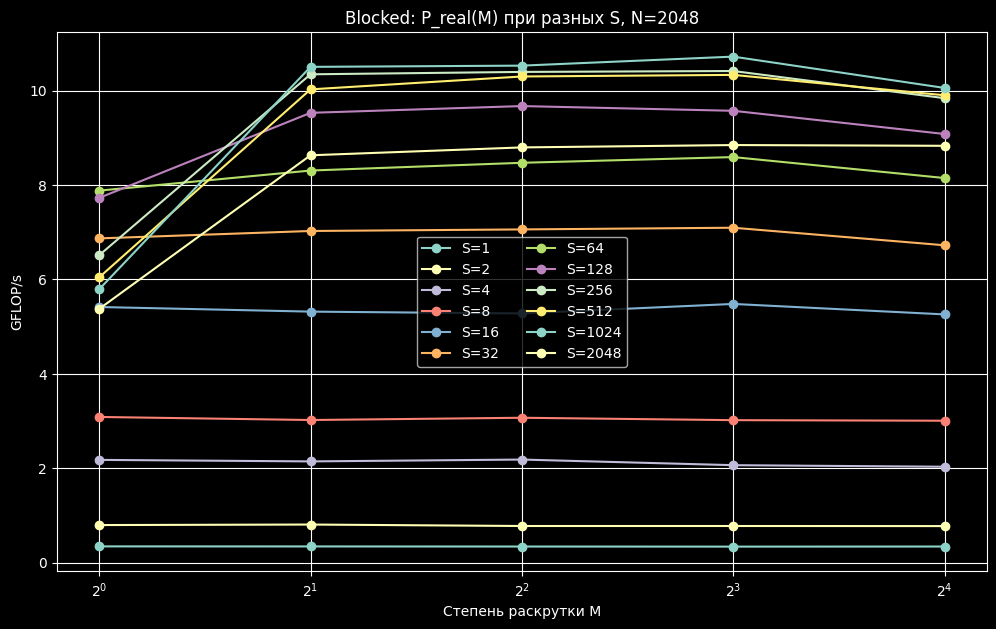

In [18]:
N_selected = 2048

part = df_blocked[df_blocked["N"] == N_selected].copy()
S_values = sorted(part["S"].unique())

plt.figure(figsize=(12, 7))
for S in S_values:
    sub = part[part["S"] == S].sort_values("M")
    plt.plot(sub["M"], sub["perf_gflops"], marker="o", label=f"S={S}")

plt.xscale("log", base=2)
plt.xlabel("Степень раскрутки M")
plt.ylabel("GFLOP/s")
plt.title(f"Blocked: P_real(M) при разных S, N={N_selected}")
plt.legend(ncol=2)
plt.show()

In [19]:
classic_df = df_summary[df_summary["algorithm"] == "Classic"][["N", "time_ms", "perf_gflops"]].rename(
    columns={"time_ms": "classic_time_ms", "perf_gflops": "classic_perf"}
)

tr_prep_df = df_summary[df_summary["algorithm"] == "Transposed (+prep)"][["N", "time_ms", "perf_gflops"]].rename(
    columns={"time_ms": "tr_prep_time_ms", "perf_gflops": "tr_prep_perf"}
)

tr_only_df = df_summary[df_summary["algorithm"] == "Transposed only"][["N", "time_ms", "perf_gflops"]].rename(
    columns={"time_ms": "tr_only_time_ms", "perf_gflops": "tr_only_perf"}
)

compare_transposed = classic_df.merge(tr_prep_df, on="N").merge(tr_only_df, on="N")

compare_transposed["speedup_tr_prep_vs_classic"] = compare_transposed["classic_time_ms"] / compare_transposed["tr_prep_time_ms"]
compare_transposed["speedup_tr_only_vs_classic"] = compare_transposed["classic_time_ms"] / compare_transposed["tr_only_time_ms"]

compare_transposed

,N,classic_time_ms,classic_perf,tr_prep_time_ms,tr_prep_perf,tr_only_time_ms,tr_only_perf,speedup_tr_prep_vs_classic,speedup_tr_only_vs_classic
0,16,0.001,9.102,0.001,9.102,0.001,9.102,1.000000,1.000000
1,32,0.014,4.648,0.014,4.784,0.012,5.461,1.000000,1.166667
2,64,0.142,3.703,0.108,4.837,0.093,5.631,1.314815,1.526882
3,128,1.855,2.261,0.594,7.060,0.447,9.394,3.122896,4.149888
4,256,14.057,2.387,4.909,6.835,4.625,7.255,2.863516,3.039351
5,512,175.078,1.533,44.294,6.060,44.445,6.040,3.952635,3.939206
6,1024,2393.593,0.897,367.403,5.845,359.793,5.969,6.514898,6.652695
7,2048,34178.229,0.503,3074.380,5.588,3064.887,5.605,11.117113,11.151546


In [20]:
best_per_n = (
    df_summary.sort_values(["N", "perf_gflops"], ascending=[True, False])
    .groupby("N", as_index=False)
    .first()[["N", "algorithm", "time_ms", "perf_gflops", "S", "M"]]
    .rename(columns={
        "algorithm": "best_algorithm",
        "time_ms": "best_time_ms",
        "perf_gflops": "best_perf_gflops"
    })
)

best_per_n

,N,best_algorithm,best_time_ms,best_perf_gflops,S,M
0,16,Classic,0.001,9.102,16,16
1,32,Blocked,0.009,7.533,32,8
2,64,Buffered,0.055,9.550,32,8
3,128,Buffered,0.409,10.243,64,4
4,256,Blocked,3.476,9.654,256,4
5,512,Blocked,25.523,10.518,512,8
6,1024,Buffered,204.524,10.500,1024,8
7,2048,Blocked,1631.078,10.533,1024,8
